# Logistic Regression with ROC And AUC Score

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score


In [2]:
## generating 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)

In [3]:
pd.DataFrame(y).value_counts()

0
0    500
1    500
Name: count, dtype: int64

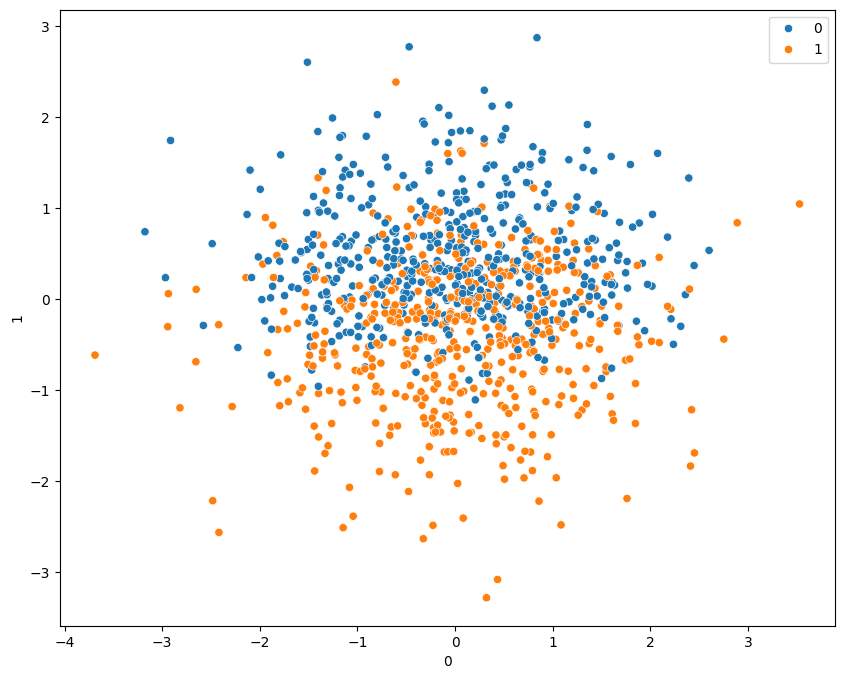

In [4]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
# we have a dummy model with default 0 as output (majority class)
dummy_model_prob = [0 for _ in range(len(y_test))]
# dummy_model_prob

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [8]:
model_prob = model.predict_proba(X_test)

In [9]:
model_prob = model_prob[:, 1] ## taking the positive value probability

In [10]:
dummy_model_auc = roc_auc_score(y_test, dummy_model_prob)
model_auc = roc_auc_score(y_test, model_prob)
print(dummy_model_auc)
print(model_auc)

0.5
0.9141713014460511


## Calculating ROC Curves

In [11]:
dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, threshold = roc_curve(y_test, model_prob)

# ROC curve

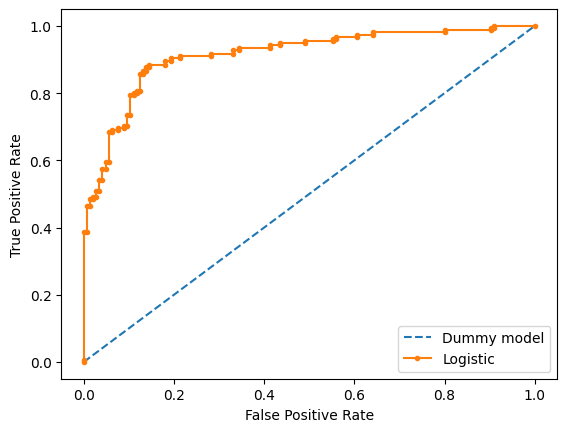

In [12]:
plt.plot(dummy_fpr, dummy_tpr, linestyle = '--', label = 'Dummy model')
plt.plot(model_fpr, model_tpr, marker = '.', label = 'Logistic')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.show()

In [13]:
threshold

array([           inf, 9.99903312e-01, 9.60819585e-01, 9.60673656e-01,
       9.42928905e-01, 9.37634035e-01, 9.35829937e-01, 9.35196941e-01,
       9.33388706e-01, 9.31568682e-01, 9.19898462e-01, 9.18320734e-01,
       9.08848834e-01, 9.04149376e-01, 8.68929260e-01, 8.68816110e-01,
       8.59454363e-01, 8.57330834e-01, 7.66609556e-01, 7.56307961e-01,
       7.47504157e-01, 7.44341554e-01, 7.38336625e-01, 7.35803961e-01,
       7.28263642e-01, 7.19672711e-01, 6.70517119e-01, 6.64080329e-01,
       5.97992204e-01, 5.63115004e-01, 5.61146495e-01, 5.42332260e-01,
       5.33104469e-01, 5.18849321e-01, 4.67721242e-01, 4.66279420e-01,
       4.53793669e-01, 4.43620311e-01, 4.30357018e-01, 4.30169935e-01,
       4.29200970e-01, 3.96059977e-01, 3.47982821e-01, 3.34198768e-01,
       3.28119070e-01, 3.07874692e-01, 2.95655789e-01, 2.40142099e-01,
       2.39704326e-01, 1.97988953e-01, 1.92236077e-01, 1.72072589e-01,
       1.68324514e-01, 1.44381585e-01, 1.41194398e-01, 1.36275906e-01,
      

## All The Threshold Values

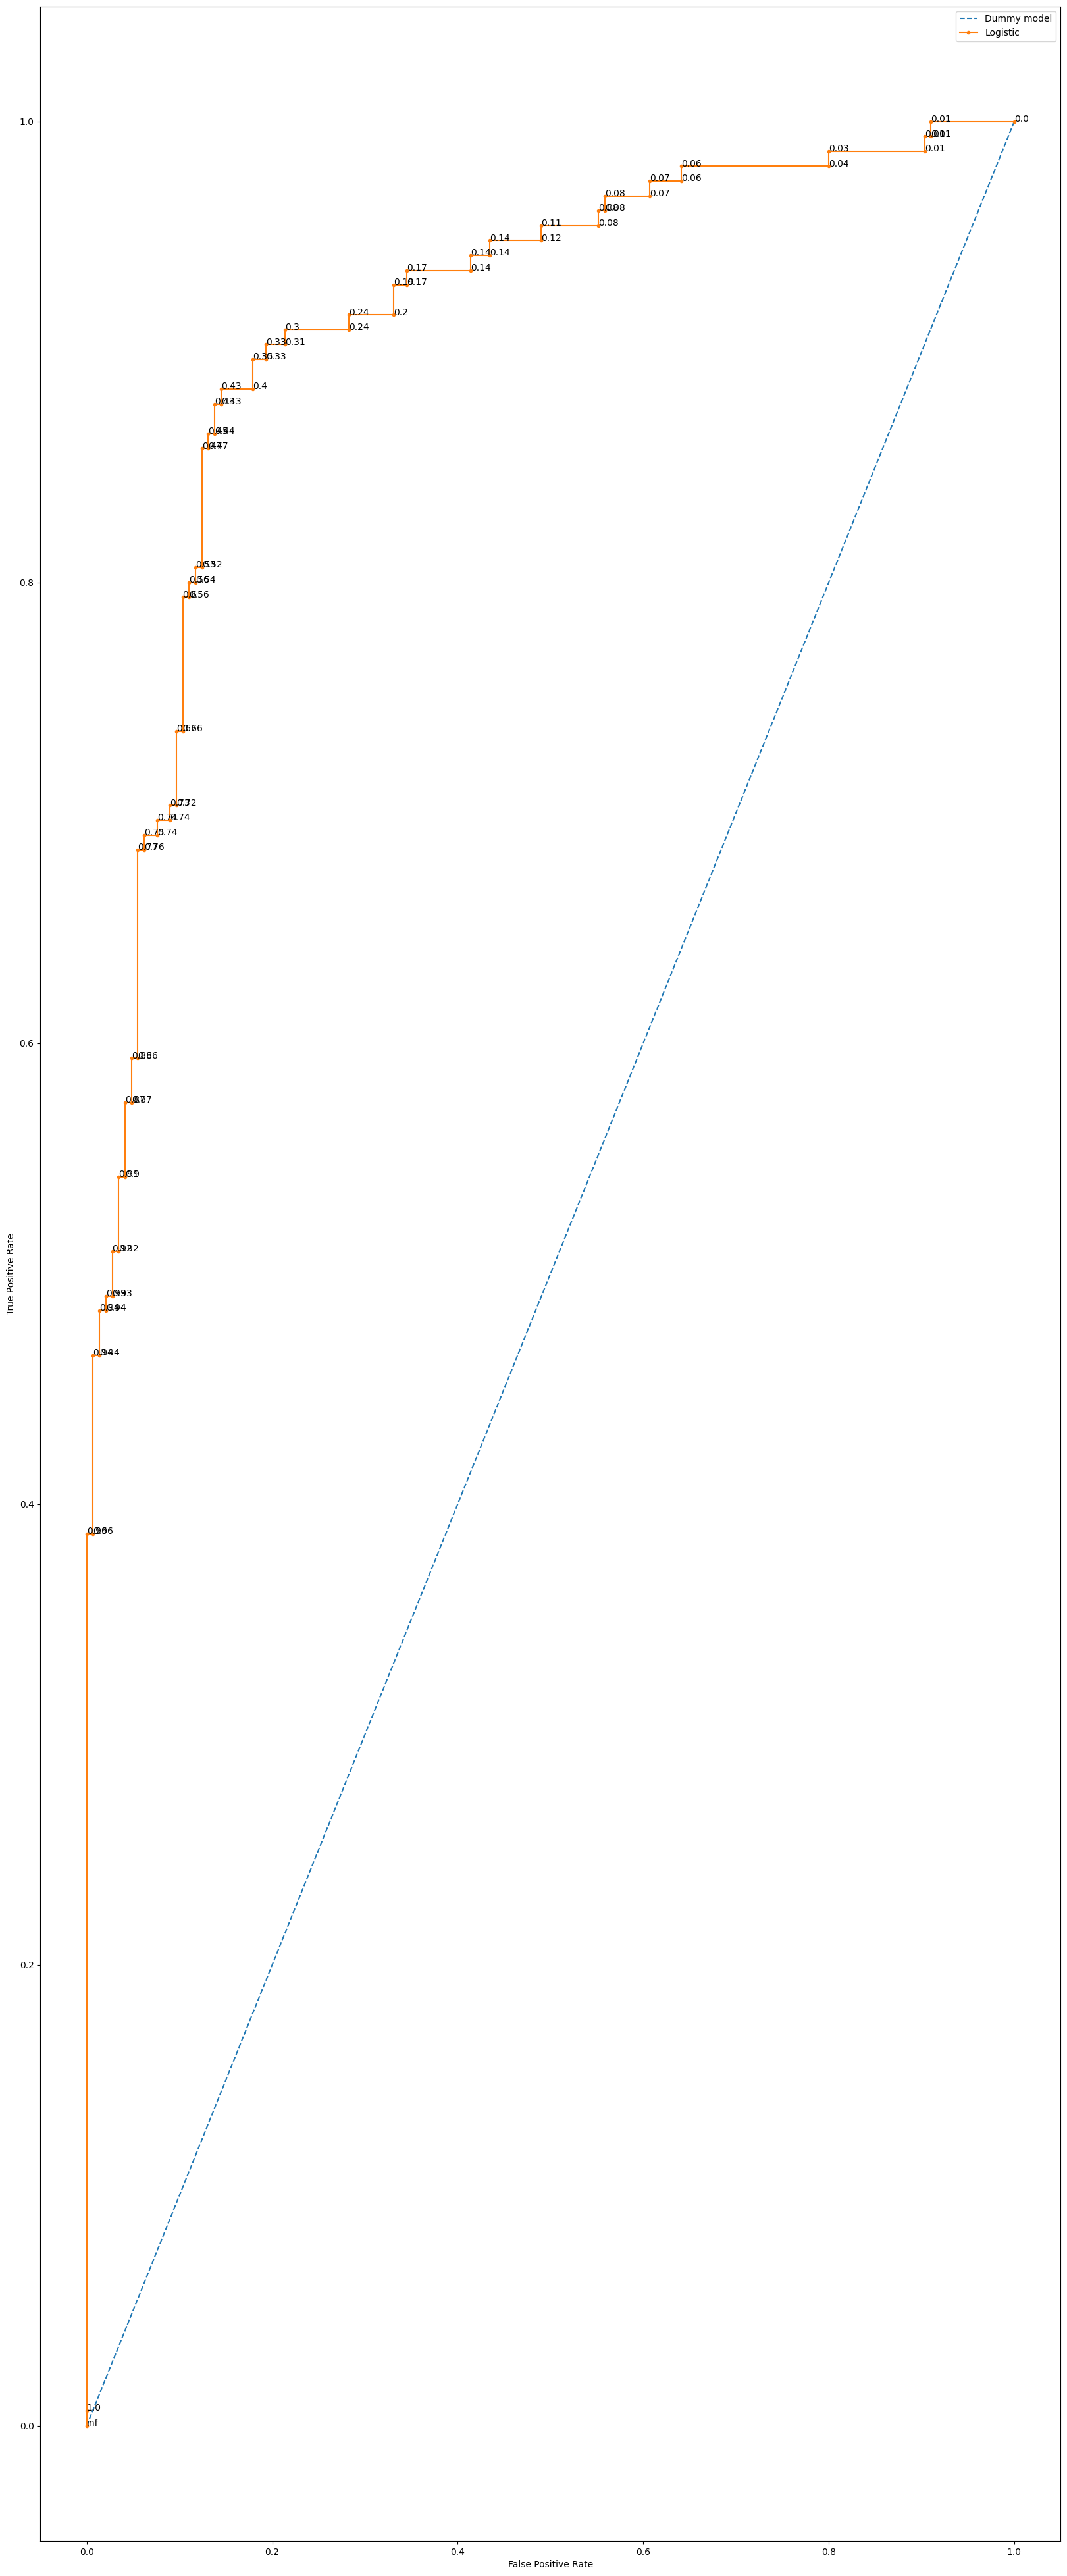

In [14]:
# Create figure and axis FIRST
fig = plt.figure(figsize=(20, 50))
ax = fig.add_subplot(111)  

ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')

for xyz in zip(model_fpr, model_tpr, threshold):
    ax.annotate('%s' % np.round(xyz[2], 2), xy=(xyz[0], xyz[1]))

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

plt.show()

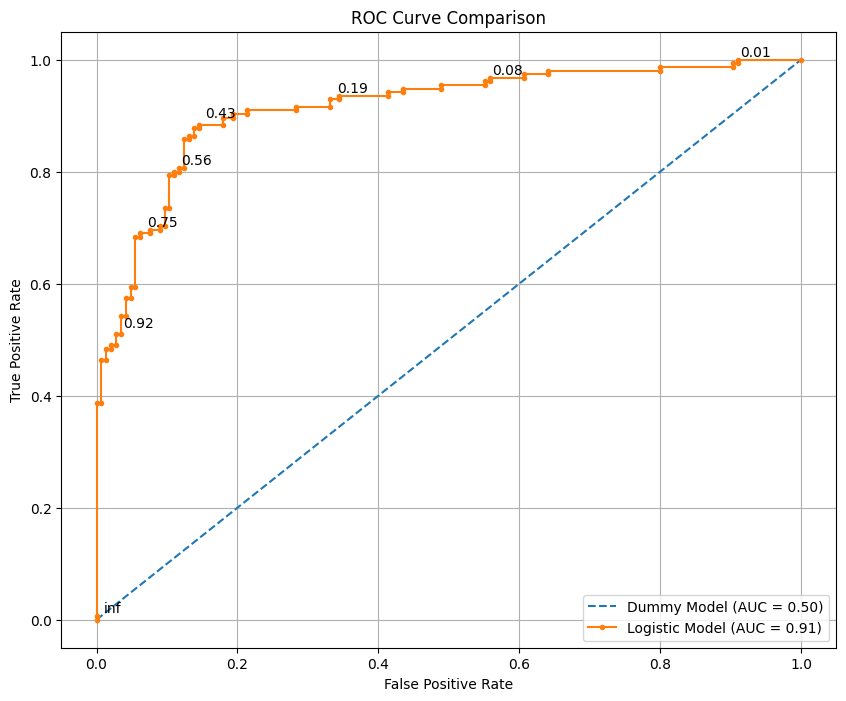

In [15]:
from sklearn.metrics import roc_curve, auc

dummy_fpr, dummy_tpr, _ = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, threshold = roc_curve(y_test, model_prob)

dummy_auc = auc(dummy_fpr, dummy_tpr)
model_auc = auc(model_fpr, model_tpr)

# Create plot
plt.figure(figsize=(10, 8))

# Plot ROC curves
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label=f'Dummy Model (AUC = {dummy_auc:.2f})')
plt.plot(model_fpr, model_tpr, marker='.', label=f'Logistic Model (AUC = {model_auc:.2f})')

for i in range(0, len(threshold), 10):
    plt.annotate(
        text=f"{threshold[i]:.2f}",
        xy=(model_fpr[i], model_tpr[i]),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()